# Coursework Set Week 6

**Common remarks**:

* Deadline: Sunday at 23:59h for the week of this task
* <font color='red'>Keep all the information in this template unaltered!</font>

**Please fill in the following fields:**

* Name: Isabelle Rosa Frank
* Username: irfrank
* Student number: S6414117
* Group (AS1, etc.): AS5

-----

In [ ]:
totalpoints = currentpoints = 0

### Exploring a HI data cube (7 pt) <font color='red'><b>COURSEWORK</b></font>
   
* Download FITS image [ngc6946.fits](https://www.astro.rug.nl/intranet/courses/PROGNUMNEW/latest/DATA/ngc6946.fits)
* Create a mosaic with 5 rows and 10 columns of channel maps for the Z indices ``range(1, 101, 2)``
* Remove axis labeling with Axes methods ``set_xticklabels([])`` and ``set_yticklabels([])``.
* If you add two channel maps you get a new map where each pixel is the sum of the two maps. If you add all channel maps (not the noisy ones), you get a so called *total HI* map.

    * Select a suitable range of channel maps and sum them to get a total HI map. Make a plot of this map
    * Label the axes with the header values of ``CTYPE1`` and ``CTYPE2``.
    * Make a locatable colorbar and label its Y axis with the header value of ``BUNIT``. 
        
* A *position velocity* (PV) map is a slice through the data at one fixed spatial position. 
   It tells you something about how the velocities in a galaxy behave as function of position 
   and one fixed position.   
   In NumPy jargon a PV map can be an YZ slice or a XZ slice. 

    * Plot a PV map for a fixed Right Ascension (R.A.) with index 50.
    * Plot a vertical line at Dec. with index 40.
    * Label the axes with the header values of ``CTYPE2`` and ``CTYPE3``. <br>&nbsp;</br>
        
* A *global HI spectral profile* is a slice in along the spectral axis at a fixed Right Ascension and Declination.
   It is a 1D curve with intensities as function of frequency (or velocity). It shows you at which 
   velocity most of the gas is rotating in a galaxy given a position in R.A. and Dec.

    * Plot a global profile at R.A. with index 50 and Dec. with index 40.
    * Label the plot axes with the header values of ``CTYPE3`` and ``BUNIT``. <br>&nbsp;</br>

* What is the relation between this profile and the vertical line in the previous plot of the PV diagram?   

**Answers**:

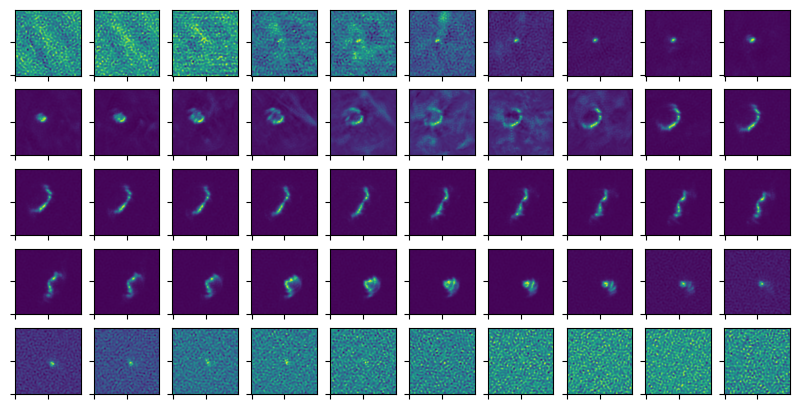

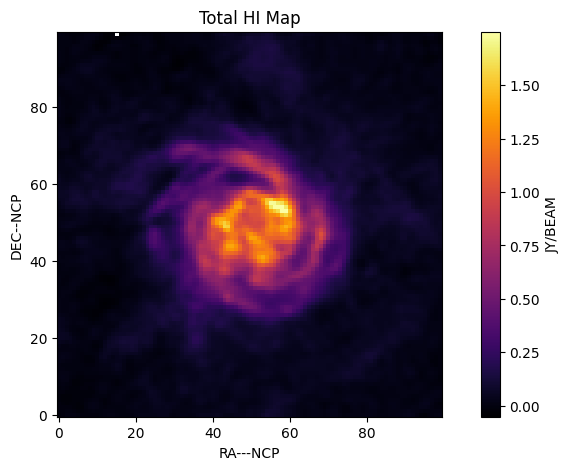

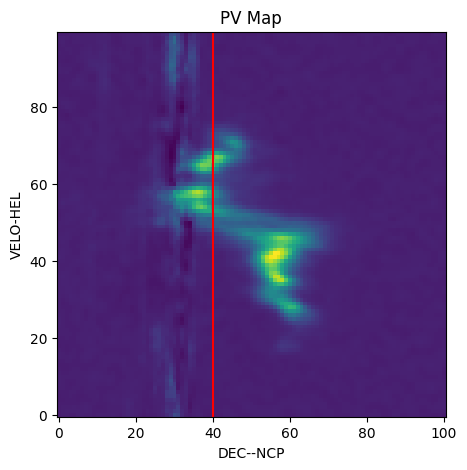

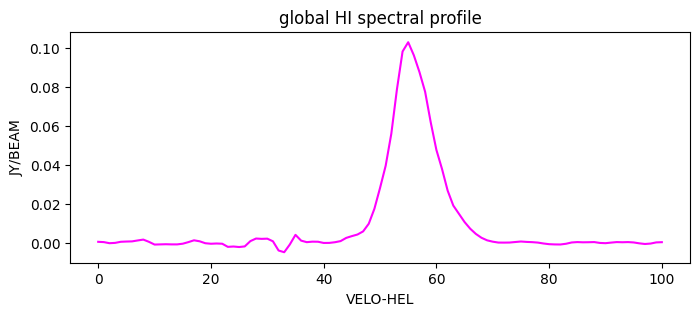

In [33]:
from astropy.io import fits
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.pyplot import figure

hdulist = fits.open('ngc6946.fits')
dat = hdulist[0].data
header = hdulist[0].header

#create mosaic of 5x10 channel maps
z_indices= range(1, 101, 2)
row= 5
column= 10

fig, frame= plt.subplots(row, columns, figsize=(10, 5))

for i, z in enumerate (z_indices):
    c= i%column
    r=i//column
    ax=frame[r,c]
    ax.imshow(dat[z], origin='lower', cmap='viridis')
    ax.set_yticklabels([])
    ax.set_xticklabels([])
    
plt.show()


#total hi map
good_channels=range(20, 80)
total_HI=np.sum(dat[good_channels,:,:], axis=0)
fig1, frame1= plt.subplots(figsize=(10, 5))
img=frame1.imshow(total_HI, origin='lower', cmap='inferno')
frame1.set_xlabel(header['CTYPE1'])
frame1.set_ylabel(header['CTYPE2'])

#colorbar
plt.colorbar(img, label=header["BUNIT"])

frame1.set_title("Total HI Map")
plt.show()


#PV
RA_idx= 50
DE_idx= 40

pv_map= dat[:,:,RA_idx]
fig2, frame2= plt.subplots(figsize=(6, 5))
img=frame2.imshow(pv_map.T, origin='lower', cmap='viridis')
frame2.axvline(x=DE_idx, color='red')
frame2.set_xlabel(header['CTYPE2'])
frame2.set_ylabel(header['CTYPE3'])
frame2.set_title('PV Map')
plt.show()

#global HI spectral profile
RA_idx= 50
DE_idx= 40

profile= dat[:,DE_idx,RA_idx]
plt.figure(figsize=(8,3))
plt.plot(profile, color='magenta')
plt.xlabel(header['CTYPE3'])
plt.ylabel(header['BUNIT'])
plt.title('global HI spectral profile')
plt.show()

#What is the relation between this profile and the vertical line in the previous plot of the PV diagram?
#The profile is the 1D version of the PV Map along the vertical line that was plotted

In [ ]:
# Leave unaltered
totalpoints += 7
currentpoints += 0.0

### Galaxy Colour (5 pt) <font color='red'><b>COURSEWORK</b></font>
   
Download [SDSS_DR17_galaxies.fits](https://brightspace.rug.nl/content/enforced/457626-WBAS018-05.2025-2026.1/SDSS_DR17_galaxies.fits), which contains apparent magnitude in ``u, g, r, i, z`` five SDSS broad-band filters.

* Create a Pandas DataFrame from the FITS table.
* Filter out any data with negative values.
* Calculate every combination of colours from each broad band filter, e.g. u-g, u-r, u-i, u-z, g-r, ......
* Calculate the mean and standard deviation of the each colour.
* Use Object-Oriented Plotting to create a corner plot using derived colours.
* Set the xlim and ylim to be within three standard deviation.
* Add title for each histogram with information of the mean and standard deviation of each colour in the format of $\mu\pm\sigma$
 (to one decimal place).

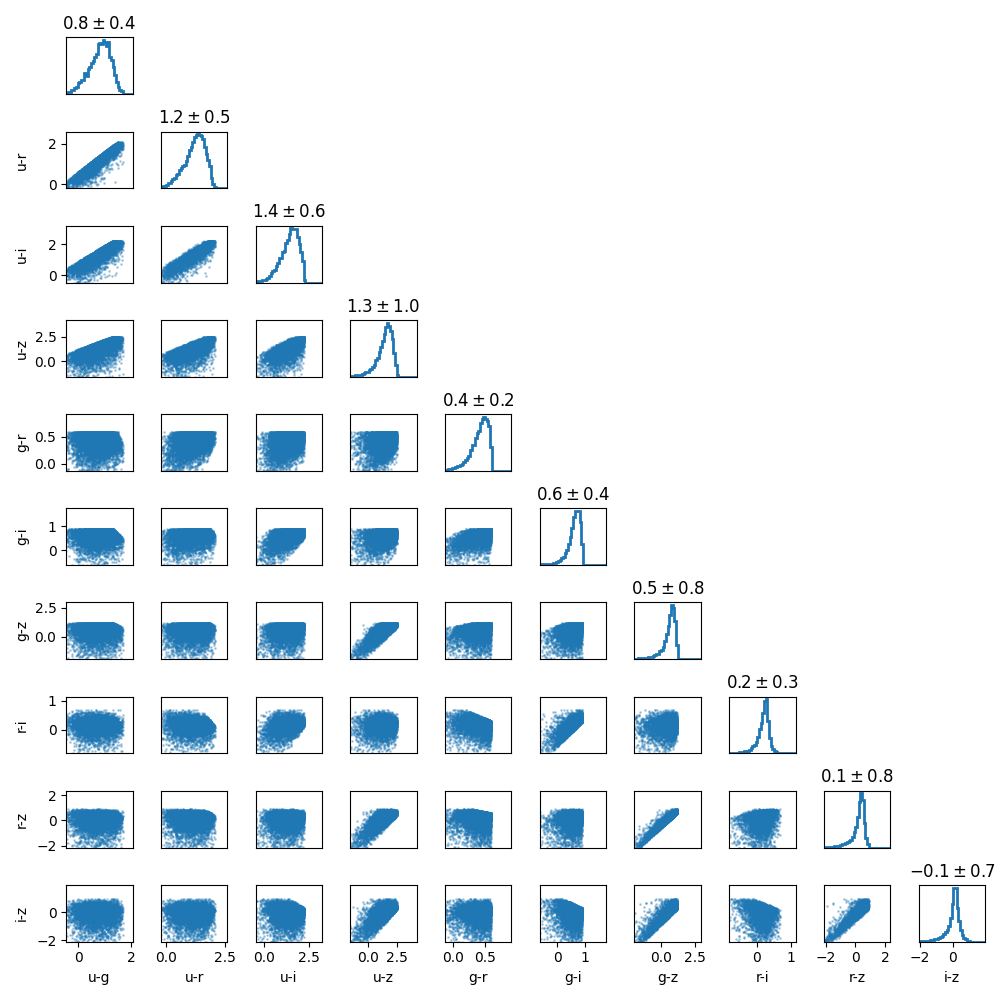
   
**Plot and answer**:

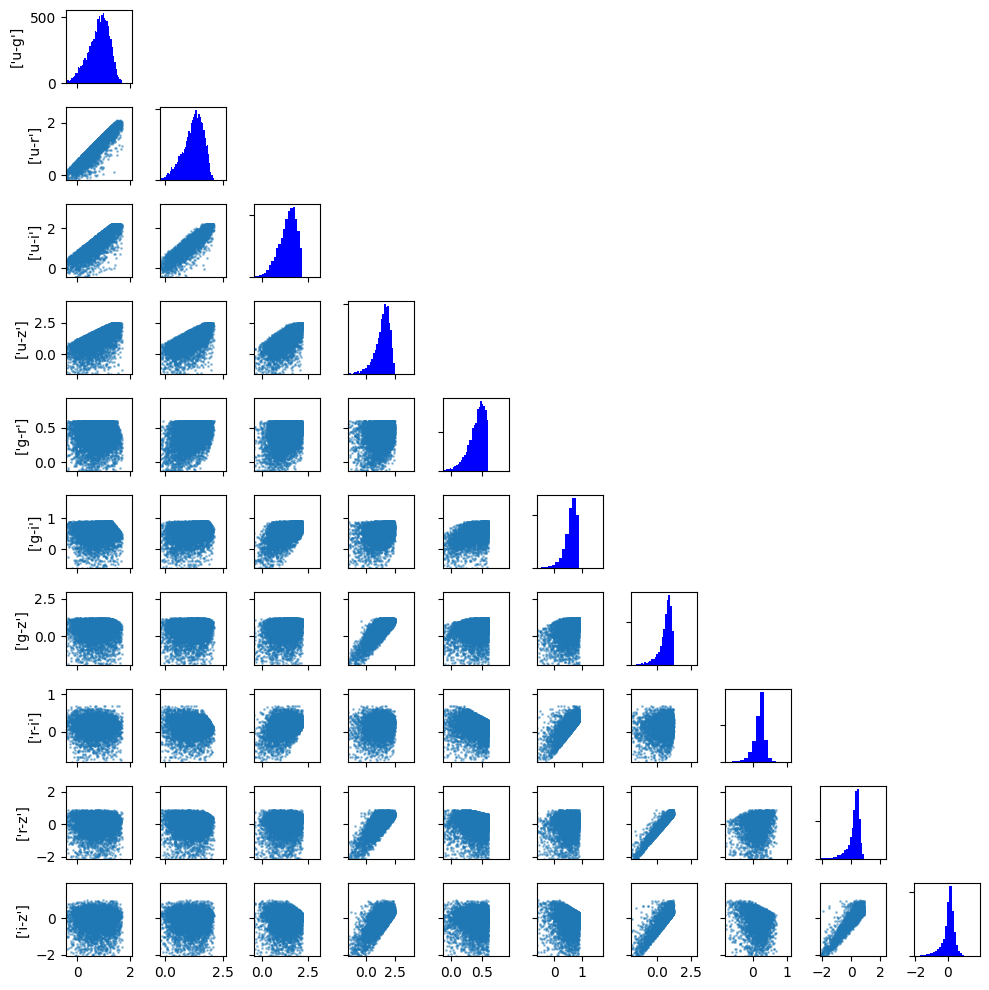

In [87]:
import pandas as pd
import numpy as np
from astropy.io import fits
import matplotlib.pyplot as plt

#open the file
hdulist = fits.open('SDSS_DR17_galaxies.fits')
data = hdulist[1].data

#create Pandas DataFrame
df=pd.DataFrame(np.array(data).byteswap().view(np.array(data).dtype.newbyteorder('=')))

#get u, g, r, i, z
bands=['u','g','r','i','z']
df=df[bands]

#filter out any negative values with a mask
filter=['u','g','r','i','z']
for f in filter:
    df=df[df[f]>=0]

#calculate colors
color_df=pd.DataFrame()
for i in range(len(bands)):
    for j in range(i+1, len(bands)):
        c1=bands[i]
        c2=bands[j]
        name=c1+'-'+c2
        color_df[name]=df[c1]-df[c2]
        
#calculate mean and standard deviation
mean={}
std={}

for col in color_df.columns:
    mean[col]=np.mean(color_df[col])
    std[col]=np.std(color_df[col])
    
#corner plot
colors=list(color_df.columns)
n=len(colors)

fig, frame = plt.subplots(n,n, figsize=(10,10))

for i in range(n):
    for j in range(n):
        ax=frame[i,j]
        
        #hide the upper triangle
        if j> i:
            ax.set_visible(False)
            continue
        
        ycol=colors[i]
        xcol=colors[j]
        
        
        if i==j:  #histogram
            ax.hist(color_df[xcol], bins=100, color='blue')
            mean_val=mean[xcol]
            std_val=std[xcol]
            ax.set_xlim(mean_val-3*std_val, mean_val+3*std_val)
        else:  #scatter plot
            ax.scatter(color_df[xcol], color_df[ycol], s=1, alpha=0.4)
            ax.set_xlim(mean[xcol]-3*std[xcol], mean[xcol]+3*std[xcol])
            ax.set_ylim(mean[ycol]-3*std[ycol], mean[ycol]+3*std[ycol])
        
        #hide axis labels
        if j>0:
            ax.set_yticklabels([])
        else:
            ax.set_ylabel([ycol])  #set the y-axis label for first column
        if i<n-1:
            ax.set_xticklabels([])

plt.tight_layout()
plt.show()

In [ ]:
# Leave unaltered
totalpoints += 5
currentpoints += 0.0

### Astroquery: retrieving SDSS image and spectra (5 pt) <font color='red'><b>COURSEWORK</b></font>

Spiral galaxy M77 (NGC 1068) is a bright galaxy known for hosting an active galactic nucleus (AGN). With Astropy package, we construct M77's coordinate using the code below.

```python
from astropy import coordinates as coords

# Coordinates of M77
ra = 40.6696  # degrees
dec = -0.0133  # degrees
pos = coords.SkyCoord(ra, dec, unit="deg", frame="icrs")
```

* Use ``astroquery`` ([search regions](https://astroquery.readthedocs.io/en/latest/sdss/sdss.html#searching-regions-and-multiple-objects)) on the ``pos``, containing RA and DEC of this galaxy, to retrieve its SDSS spectrum using ``get_spectra()``. The search radius sets as ``10 arcsec`` for searching.
* The return object of ``get_spectra()`` is a list of [HDUList](https://docs.astropy.org/en/stable/io/fits/api/hdulists.html#astropy.io.fits.HDUList) objects.
* Retrieve flux and wavelengths using columns ``flux`` and ``loglam``. Note that the wavelength is in logarithmic value, you need to convert it back to a linear scale.
* The redshift of M77 is approximately ``z~0.0038``. Calculating the rest-frame wavelengths.
* Use Object-Oriented Plotting to plot:
    * a rest-frame spectrum which corrects the redshift effect (top)
    * a zoom-in spectrum at wavelength between 6450 and 6650 angstrom (bottom)
* Draw vertical lines for H$\alpha$ lines in both frames. Label them and show with legend.
* Draw vertical lines indicating approximately where the peak of the flux is, which in fact should be the H$\alpha$ line.
* An example plot is shown below.
* Calculating the velocity indicated by the difference between the two wavelengths.
* Share your thought using a markdown on what might be causing this offset. This question will not be graded, and meant to train a bit your scientific thinking. Feel free to express any thought.

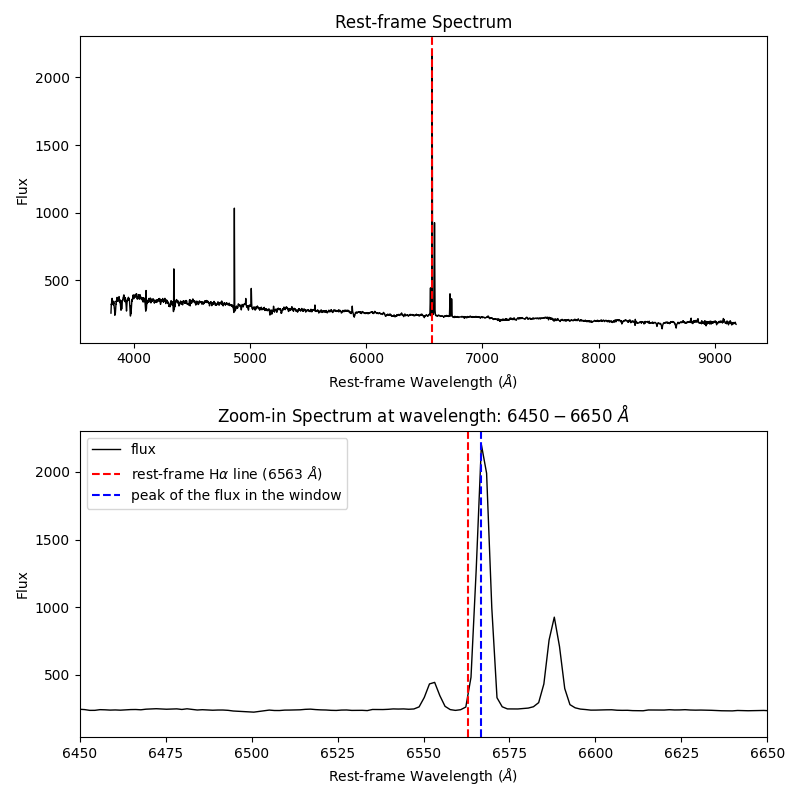

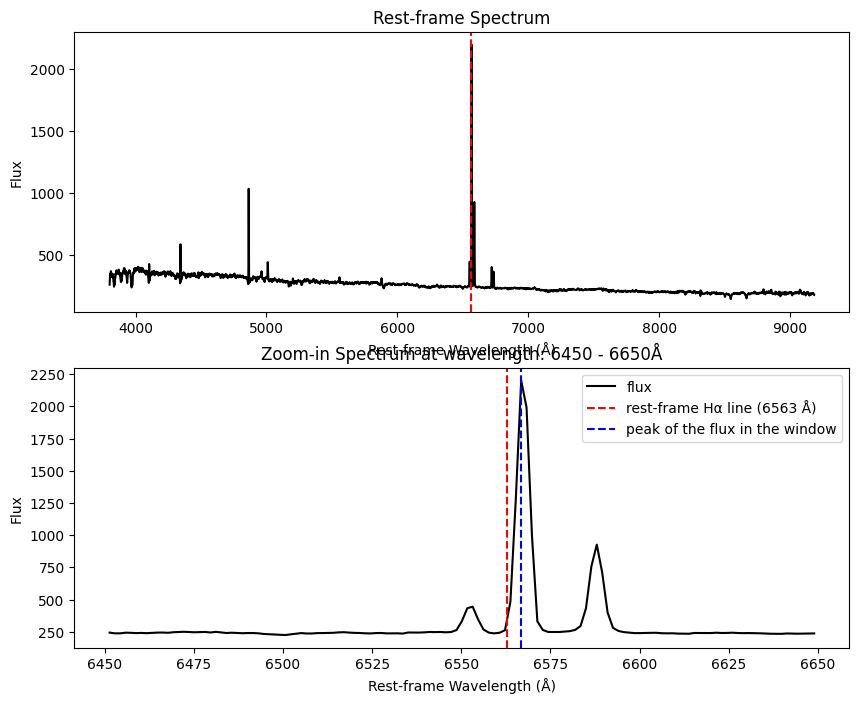

velocity:1140.00 km/s


In [47]:
from astropy import coordinates as coords
from astroquery.sdss import SDSS
import numpy as np
import matplotlib.pyplot as plt

# Coordinates of M77
ra = 40.6696  # degrees
dec = -0.0133  # degrees
pos = coords.SkyCoord(ra, dec, unit="deg", frame="icrs")

#get SDSS spectra within 10 arcsec
xid=SDSS.query_region(pos, radius='10 arcsec',spectro=True)

#get spectra
spec_list=SDSS.get_spectra(matches=xid)
spec=spec_list[0]

#flux and wavelength
flux=spec[1].data['flux']
loglam=spec[1].data['loglam']
wavelength=10**loglam

#rest wavelength
z=0.0038
wavelength_rest=wavelength /(1+z)

#index of max flux
idx=np.argmax(flux[zoom_mask])

#mark the vertical lines
ha_rest=6562.8          #(Å)
ha_obs=ha_rest *(1+z)
peak_wavelength=wavelength_rest[zoom_mask][idx]

#plot
fig, (frame1, frame2)=plt.subplots(2,1, figsize=(10,8), sharex=False)

frame1.plot(wavelength_rest, flux, color='black')
frame1.set_xlabel('Rest-frame Wavelength (Å)')
frame1.set_ylabel('Flux')
frame1.axvline(ha_rest, color='red', linestyle='--')
frame1.set_title('Rest-frame Spectrum')

zoom_mask=(wavelength_rest >=6450) & (wavelength_rest<=6650)
frame2.plot(wavelength_rest[zoom_mask], flux[zoom_mask], color='black', label='flux')
frame2.set_xlabel('Rest-frame Wavelength (Å)')
frame2.set_ylabel('Flux')
frame2.axvline(ha_rest, color='red', linestyle='--', label='rest-frame Hα line (6563 Å)')
frame2.axvline(peak_wavelength, color='blue', linestyle='--', label='peak of the flux in the window')
frame2.set_title('Zoom-in Spectrum at wavelength: 6450 - 6650Å')

plt.legend()
plt.show()

#velocity
delta_lambda=ha_obs - ha_rest
c=3e5   #km/s
v=delta_lambda/ha_rest*c

print(f"velocity:{v:.2f} km/s")

In [ ]:
# Leave unaltered
totalpoints += 5
currentpoints += 0.0

### Comparing an image in different color scales (stretches) (4pt) <font color='red'><b>COURSEWORK</b></font>

Given is the Blaauw observatory FITS file
[20210422_Li_.00000066.FIT](https://www.astro.rug.nl/intranet/courses/PROGNUMNEW/latest/DATA/20210422_Li_.00000066.FIT)

Use the `imdisplay()` function from the notebook *The art of plotting an image* to make a mosaic with this image using all the different scales (stretches) available to that function. 

* Add a proper docstring to the function.
* Show the used scale in the title of the plot. (hints: tight_layout, fontsize).
* Also include the image without scaling as the first plot in the mosaic.

**Answer**:

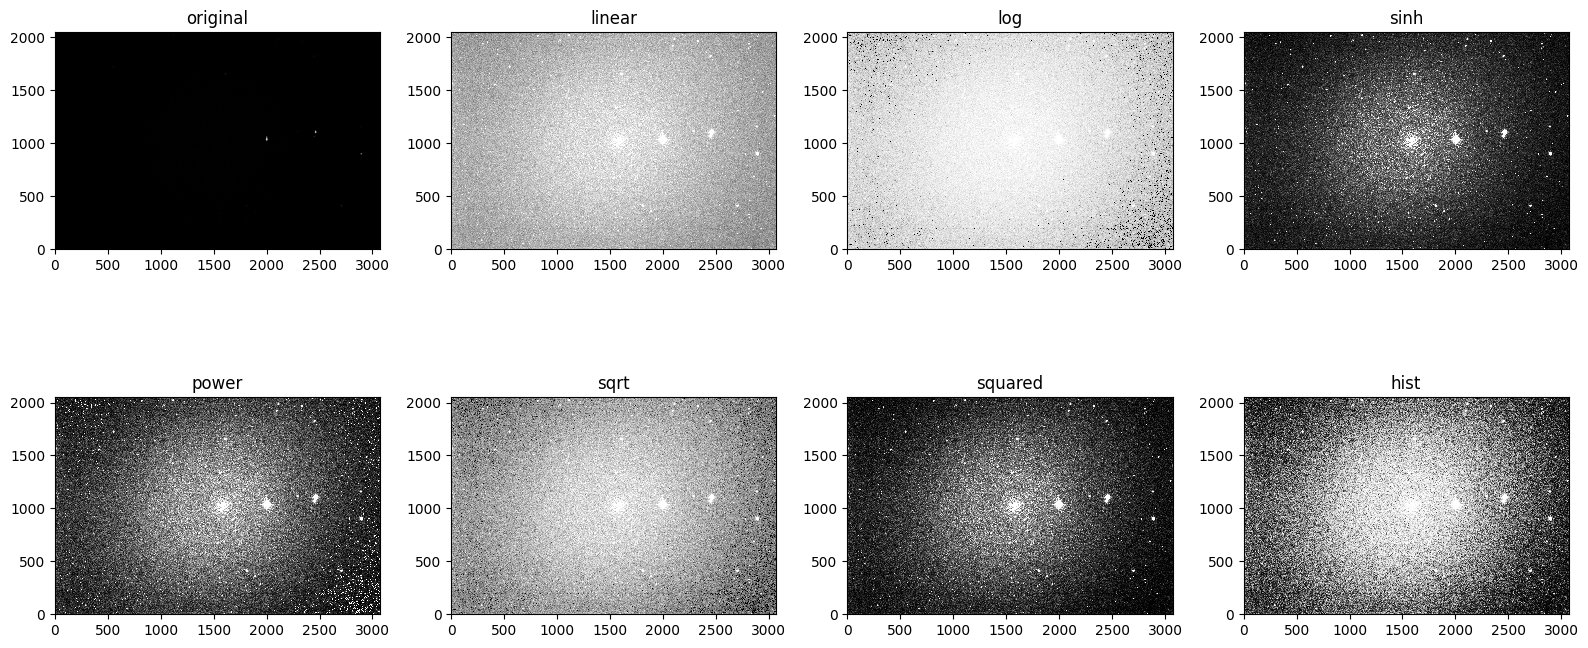

In [60]:
from astropy.visualization import ImageNormalize
from astropy.visualization import SinhStretch, AsymmetricPercentileInterval, LinearStretch,\
                                  LogStretch, PowerStretch, SqrtStretch, SquaredStretch,\
                                  HistEqStretch, ZScaleInterval
import numpy as np
import matplotlib.pyplot as plt
from astropy.io import fits


hdulist = fits.open("20210422_Li_.00000066.FIT")
image_data = hdulist[0].data

def imdisplay(data,
              ax,
              vmin=None, vmax=None,
              percentlow=1, percenthigh=99,
              zscale=False,
              scale='linear',
              power=1.5,
              cmap='gray',
              **kwargs):
    """
    parameters:
    data: 2d data array
    ax: axis object where data willbe plotted
    vmin: minimum value for scaling
    vmax: maximum value for scaling
    percentlow: lower percentile for sclaing
    percenthigh: upper percentile for scaling
    zscale: whether or not to use the zscale scaling
    scale: scaling method applied
    power: exponent for scaling
    cmap: scolormpa to show the image
    """
    
    if zscale:
        # Always overwrite vmin and vmax
        interval = ZScaleInterval()
        vmin, vmax = interval.get_limits(data)
    if vmin is None or vmax is None:
        interval = AsymmetricPercentileInterval(percentlow, percenthigh)
        vmin2, vmax2 = interval.get_limits(data)
        if vmin is None:
            vmin = vmin2
        if vmax is None:
            vmax = vmax2

    if scale == 'linear':
        stretch = LinearStretch(slope=0.5, intercept=0.5)
    if scale == 'sinh':
        stretch = SinhStretch()
    if scale == 'log':
        stretch = LogStretch()
    if scale == 'power':
        stretch = PowerStretch(power)
    if scale == 'sqrt':
        stretch = SqrtStretch()
    if scale == 'squared':
        stretch = SquaredStretch()
    if scale == 'hist':
        stretch = HistEqStretch(data)  # Needs argument data and data min, max for vmin, vmax
        vmin = data.min(); vmax = data.max()

    norm = ImageNormalize(vmin=vmin, vmax=vmax, stretch=stretch)
    return ax.imshow(data, interpolation='none', origin='lower', norm=norm, cmap=cmap, **kwargs)


all_scales=['none','linear','log','sinh','power','sqrt','squared','hist']
#show the plot
fig, frame = plt.subplots(2,4, figsize=(16, 8))
frames=frame.flatten()

for i, scale in enumerate (all_scales):
    ax=frames[i]
    if scale=='none':
        ax.imshow(image_data, origin='lower', cmap='gray')
        ax.set_title('original')
    else:
        imdisplay(image_data, ax, scale=scale)
        ax.set_title(scale)

plt.tight_layout()
plt.show()

In [ ]:
# Leave unaltered
totalpoints += 4
currentpoints += 0.0

### Image stacking optical data (6pt) <font color='red'><b>COURSEWORK</b></font>

Select one of the suitable observations from the next table or
find one yourself in the
[Blaauw Observatory Overview](https://www.astro.rug.nl/intranet/sterrenwacht/files.py)

* Following the stacking procedure in the notebook about image stacking for the data you selected. Show the result.
* Align the images and repeat the stacking procedure. Show the result.
* Remove all unnecessary code and markdown text.
* Include code and result in your report.

| nr | Folder on data server |
| :---  | :---: |
| 2  | ``/net/dataserver3/data/users/sterrenwacht/images/210418/STL-6303E/i/`` |
| 3  | ``/net/dataserver3/data/users/sterrenwacht/images/190515/STL-6303E/i/`` |
| 4  | ``/net/dataserver3/data/users/sterrenwacht/images/190428/STL-6303E/i/`` |
| 5  | ``/net/dataserver3/data/users/sterrenwacht/images/190419/STL-6303E/i/`` |
| 6  | ``/net/dataserver3/data/users/sterrenwacht/images/180504/STL-6303E/i/`` |
| 7  | ``/net/dataserver3/data/users/sterrenwacht/images/160913/STL-6303E/i/`` |
| 8  | ``/net/dataserver3/data/users/sterrenwacht/images/140912/STL-6303E/i/`` |
| 9  | ``/net/dataserver3/data/users/sterrenwacht/images/131001/STL-6303E/i/`` |
| 10 | ``/net/dataserver3/data/users/sterrenwacht/images/101212/STL-6303E/i/`` |

**Code and plot**:

180420_Li_00000022.fits
180420_Li_00000040.fits
180420_Li_00000026.fits
180420_Li_00000044.fits
180420_Li_00000032.fits


TypeError: buffer is too small for requested array

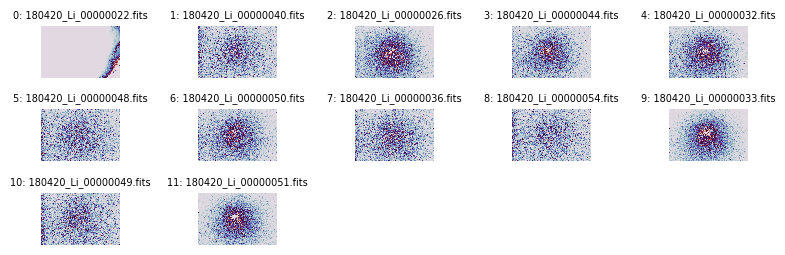

In [32]:
from pathlib import Path

datadir = "/Users/users/irfrank/VIRGO01"  # Replace by your own data folder (not in home!)
excludes = ['BIAS', 'FLAT', 'DARK']  # Exclude these images if these are opart of the file name

path = Path(datadir)
filepaths = []
for filepath in path.iterdir():
    if filepath.suffix.lower() in ['.fits', '.fit', '.fts']:
        if not any(ext in filepath.name for ext in excludes):
            filepaths.append(filepath)

# Print first 5 file names
for f in filepaths[:5]:
    print(f.name)

    
from astropy.visualization import ImageNormalize
from astropy.visualization import SinhStretch, AsymmetricPercentileInterval, LinearStretch,\
                                  LogStretch, PowerStretch, SqrtStretch, SquaredStretch,\
                                  HistEqStretch, ZScaleInterval

def imdisplay(data,
              ax,
              vmin=None, vmax=None,
              percentlow=1, percenthigh=99,
              zscale=False,
              scale='linear',
              power=1.5,
              cmap='gray',
              **kwargs):
    if zscale:
        # Always overwrite vmin and vmax
        interval = ZScaleInterval()
        vmin, vmax = interval.get_limits(data)
    if vmin is None or vmax is None:
        interval = AsymmetricPercentileInterval(percentlow, percenthigh)
        vmin2, vmax2 = interval.get_limits(data)
        if vmin is None:
            vmin = vmin2
        if vmax is None:
            vmax = vmax2

    if scale == 'linear':
        stretch = LinearStretch(slope=0.5, intercept=0.5)
    if scale == 'sinh':
        stretch = SinhStretch()
    if scale == 'log':
        stretch = LogStretch()
    if scale == 'power':
        stretch = PowerStretch(power)
    if scale == 'sqrt':
        stretch = SqrtStretch()
    if scale == 'squared':
        stretch = SquaredStretch()
    if scale == 'hist':
        stretch = HistEqStretch(data)  # Needs argument data and data min, max for vmin, vmax
        vmin = data.min(); vmax = data.max()

    norm = ImageNormalize(vmin=vmin, vmax=vmax, stretch=stretch)
    return ax.imshow(data, interpolation='none', origin='lower', norm=norm, cmap=cmap, **kwargs)


from matplotlib.pyplot import figure, show
from astropy.io import fits
from math import ceil

fig = figure(figsize=(8,6), tight_layout=True)
count = 1
ncols = 5
nrows = ceil(len(filepaths)/ncols)
for i, filepath in enumerate(filepaths):
    hdulist = fits.open(filepath)
    ax = fig.add_subplot(nrows, ncols, count)
    ax.axis('off')
    imdisplay(hdulist[0].data, ax, scale='power', power=3, cmap='twilight')
    ax.set_title(f"{i}: {filepath.name}", fontsize=7)
    count += 1
    hdulist.close()
show()


In [ ]:
# Leave unaltered
totalpoints += 6
currentpoints += 0.0

## Finishing up

**Please read the section about your report in the task documentation very carefully before submitting it to BrightSpace.**

------------

## T.A. Grading


In [ ]:
# Leave unaltered
taskgrade = round(10*currentpoints/totalpoints, 1) if totalpoints != 0 else 0
print(f"Total number of points: {totalpoints}. Student score: {currentpoints}.  Task Grade = {taskgrade}")